In [1]:
import sys, pathlib, time, warnings, json, collections
import numpy as np
import matplotlib.pyplot as plt
import cv2
import plotly.graph_objects as go
import c3d

HERE = pathlib.Path.cwd()
if HERE.name != "mhr_posing":
    HERE = HERE / "mhr_posing"                  # started from the project root
ROOT = HERE.parent
sys.path.insert(0, str(HERE))                    # this folder's analytic_ik wins
sys.path.append(str(ROOT))                       # mhr_kit lives up there

import analytic_ik as ik
from mhr_kit.model import faces
from mhr_kit import render

rig = ik.Rig() 

In [2]:
# ROOT = pathlib.Path.cwd()
CAMERAS = ROOT / "ASPset" / "ASPset-510 3" / "test" / "cameras"
VIDEOS  = ROOT / "ASPset" / "ASPset-510" / "test" / "videos"
JOINTS_DIR = ROOT / "ASPset" / "ASPset-510 4" / "test" / "joints_3d"

SKELETON = [("pelvis", "neck"), ("neck", "head"), ("head", "head_top"),
            ("neck", "left_shoulder"), ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),
            ("neck", "right_shoulder"), ("right_shoulder", "right_elbow"), ("right_elbow", "right_wrist"),
            ("pelvis", "left_hip"), ("left_hip", "left_knee"), ("left_knee", "left_ankle"),
            ("pelvis", "right_hip"), ("right_hip", "right_knee"), ("right_knee", "right_ankle")]

def load_clip(path):
    with open(path, "rb") as f:
        return np.array([points for _, points, _ in c3d.Reader(f).read_frames()])[:, :, :3]

def read_camera(subject, view):
    data = json.loads((CAMERAS / subject / f"{subject}-{view}.json").read_text())
    return (np.array(data["intrinsic_matrix"]).reshape(3, 4),
            np.array(data["extrinsic_matrix"]).reshape(4, 4))

def project(points_mm, K, E):
    homogeneous = np.concatenate([points_mm, np.ones((len(points_mm), 1))], axis=1)
    camera_space = (E @ homogeneous.T).T[:, :3]
    image = (K[:, :3] @ camera_space.T).T
    return image[:, :2] / image[:, 2:3]

def back_to_aspset(points_cm):
    """The exact inverse of targets_from_aspset: cm and y-up back to mm and y-down."""
    return 10.0 * np.asarray(points_cm) * np.array([1.0, -1.0, -1.0])

def video_frame(path, index):
    capture = cv2.VideoCapture(str(path))
    capture.set(cv2.CAP_PROP_POS_FRAMES, index)
    ok, image = capture.read()
    capture.release()
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def draw(ax, points, colour, label=None, width=1.6):
    """Draw a 17-point skeleton. MHR is y-up; matplotlib 3D is z-up, so we plot (x, z, y)."""
    for a, b in SKELETON:
        pa, pb = points[a], points[b]
        ax.plot([pa[0], pb[0]], [pa[2], pb[2]], [pa[1], pb[1]], color=colour, lw=width,
                label=label if (a, b) == SKELETON[0] else None)
    xs = np.array([points[n] for n in points])
    ax.scatter(xs[:, 0], xs[:, 2], xs[:, 1], s=6, color=colour)

def tidy(ax, points, title):
    xs = np.array([points[n] for n in points])
    centre, reach = xs.mean(0), np.abs(xs - xs.mean(0)).max() * 1.15
    ax.set_xlim(centre[0] - reach, centre[0] + reach)
    ax.set_ylim(centre[2] - reach, centre[2] + reach)
    ax.set_zlim(centre[1] - reach, centre[1] + reach)
    ax.set_box_aspect((1, 1, 1)); ax.view_init(elev=8, azim=-75)
    ax.set(title=title, xticks=[], yticks=[], zticks=[])

/Users/rzt/Documents/mhr_env/.venv/lib/python3.13/site-packages/c3d/c3d.py:1219: UserWarning: No analog data found in file.
  warnings.warn('No analog data found in file.')


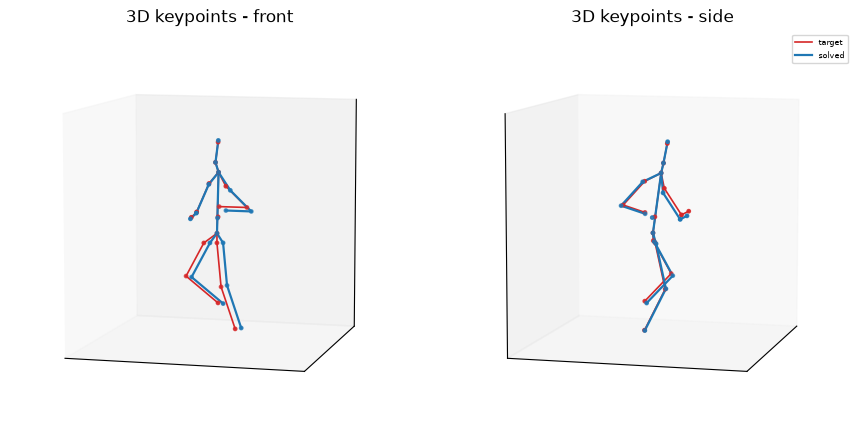

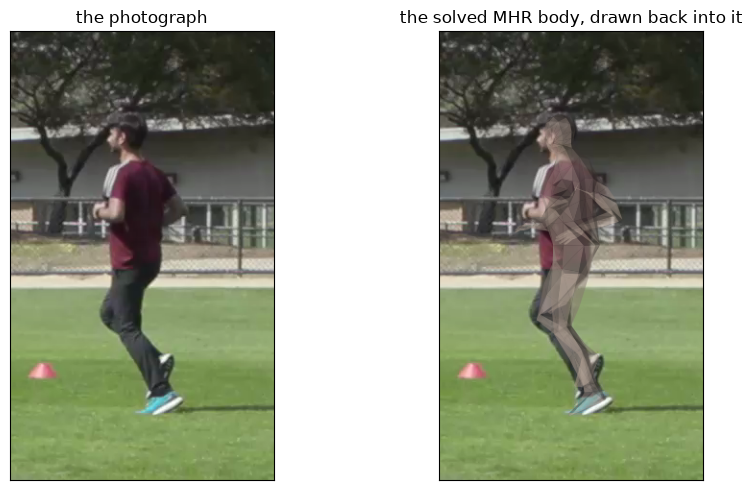

In [3]:
video_path = sorted(VIDEOS.rglob("*.mkv"))[9]
subject, clip_id, view = video_path.stem.split("-")
frames = load_clip(JOINTS_DIR / subject / f"{subject}-{clip_id}.c3d")
K, E = read_camera(subject, view)
order = list(ik.TARGET_TO_RIG)

index = 220
photo = video_frame(video_path, index)
target_points = ik.targets_from_aspset(frames[index])
pose = ik.solve(rig, target_points)
solved_points = ik.posed_keypoints(rig, pose)

mesh = ik.mesh_from_pose(rig, pose)
vertices = np.asarray(getattr(mesh, "vertices", mesh), dtype=float)
triangles = np.asarray(faces(rig.model), dtype=int)

# ---------------------------------------------------------------- 1. 3D keypoints
figure = plt.figure(figsize=(9, 4.4))
for k, (elev, azim, title) in enumerate([(8, -75, "3D keypoints - front"),
                                         (8, 15, "3D keypoints - side")]):
    ax = figure.add_subplot(1, 2, k + 1, projection="3d")
    draw(ax, target_points, "tab:red", label="target", width=1.2)
    draw(ax, solved_points, "tab:blue", label="solved")
    tidy(ax, target_points, title)
    ax.view_init(elev=elev, azim=azim)
ax.legend(loc="upper right", fontsize=6)
plt.tight_layout(); plt.show()

# ------------------------------------------------- 2. interactive 3D body model
try:

    # MHR is y-up; plot as (x, z, y) so the figure is z-up like the matplotlib views.
    vx, vy, vz = vertices[:, 0], vertices[:, 2], vertices[:, 1]
    body = go.Mesh3d(x=vx, y=vy, z=vz,
                     i=triangles[:, 0], j=triangles[:, 1], k=triangles[:, 2],
                     color="lightsteelblue", opacity=0.55, flatshading=False,
                     lighting=dict(ambient=0.55, diffuse=0.7, specular=0.15),
                     name="MHR body", hoverinfo="skip", showscale=False)

    traces = [body]
    for points, colour, name in ((target_points, "red", "target keypoints"),
                                 (solved_points, "blue", "solved keypoints")):
        for a, b in SKELETON:
            pa, pb = points[a], points[b]
            traces.append(go.Scatter3d(x=[pa[0], pb[0]], y=[pa[2], pb[2]], z=[pa[1], pb[1]],
                                       mode="lines", line=dict(color=colour, width=4),
                                       name=name, legendgroup=name,
                                       showlegend=(a, b) == SKELETON[0], hoverinfo="skip"))
        names = list(points)
        xyz = np.array([points[n] for n in names])
        traces.append(go.Scatter3d(x=xyz[:, 0], y=xyz[:, 2], z=xyz[:, 1], mode="markers",
                                   marker=dict(size=3, color=colour), text=names,
                                   name=name, legendgroup=name, showlegend=False,
                                   hovertemplate="%{text}<extra></extra>"))

    figure3d = go.Figure(traces)
    figure3d.update_layout(
        title="the solved MHR body - drag to rotate, scroll to zoom",
        width=760, height=680, margin=dict(l=0, r=0, t=40, b=0),
        scene=dict(xaxis_title="x (cm)", yaxis_title="z (cm)", zaxis_title="y (cm)",
                   aspectmode="data",
                   camera=dict(eye=dict(x=0.0, y=-2.0, z=0.6))))
    figure3d.show()

except ImportError:
    print("plotly is not installed (`pip install plotly`) - "
          "falling back to a static 3D view of the mesh.")
    ax = plt.figure(figsize=(4.5, 6)).add_subplot(projection="3d")
    step = max(1, len(vertices) // 4000)
    ax.scatter(vertices[::step, 0], vertices[::step, 2], vertices[::step, 1],
               s=0.4, color="lightsteelblue")
    draw(ax, solved_points, "tab:blue")
    tidy(ax, solved_points, "the solved MHR body")
    plt.show()

# ------------------------------------------------------------- 3. the 2D image
# Build a camera for mhr_kit's renderer that matches ASPset's real camera.
# ASPset maps world -> camera in mm/y-down; our mesh is cm/y-up, so we fold the
# flip and the unit change into the rotation and translation.
flip = np.diag([1.0, -1.0, -1.0])
rotation = E[:3, :3] @ flip
translation = E[:3, 3] / 10.0                      # mm -> cm
camera = render.Camera(focal=float(K[0, 0]), center=(float(K[0, 2]), float(K[1, 2])),
                       size=(photo.shape[1], photo.shape[0]),
                       rotation=rotation, translation=translation)

overlay = render.render(mesh, triangles, camera, background=photo, alpha=0.55)

box = project(np.array([frames[index][ik.ASPSET_ORDER.index(n)] for n in order]), K, E)
x1, y1 = box.min(0) - 90
x2, y2 = box.max(0) + 90

figure, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(photo); axes[0].set(title="the photograph", xticks=[], yticks=[])
axes[1].imshow(overlay); axes[1].set(title="the solved MHR body, drawn back into it",
                                     xticks=[], yticks=[])
for ax in axes:
    ax.set_xlim(x1, x2); ax.set_ylim(y2, y1)
plt.tight_layout(); plt.show()